# Email Spam/Ham Classification using Naive Bayes and K-Nearest Neighbors (KNN)

**Machine Learning Laboratory — Experiment 2**

Dataset: [Kaggle Spambase Dataset](https://www.kaggle.com/datasets/somesh24/spambase)


## Aim

To classify emails as **Spam** or **Ham (not spam)** using the Spambase dataset by building and
comparing **Naive Bayes** classifiers (Gaussian, Multinomial, Bernoulli) and the
**K-Nearest Neighbors (KNN)** algorithm, and to analyze their performance, computational
complexity, and behaviour under different hyperparameter settings.


## Objectives

1. Load, clean, and explore the Spambase dataset.
2. Preprocess the data (missing value handling, duplicate removal, feature scaling).
3. Perform Exploratory Data Analysis (EDA) — class distribution, correlations, distributions.
4. Train and evaluate **GaussianNB**, **MultinomialNB**, **BernoulliNB**, and **KNeighborsClassifier**.
5. Study the effect of the neighborhood size `k` on KNN performance.
6. Tune KNN hyperparameters using **GridSearchCV** and **RandomizedSearchCV**.
7. Compare **KD-Tree** and **Ball-Tree** neighbor search strategies.
8. Validate models using **5-fold cross-validation**.
9. Analyze theoretical vs. practical (measured) computational complexity.
10. Compare all classifiers using standard metrics and visualizations, and draw conclusions.


## Theory

### Naive Bayes
Naive Bayes classifiers are probabilistic classifiers based on **Bayes' Theorem**:

P(y | x1, ..., xn) ∝ P(y) * Π P(xi | y)

They assume conditional independence of features given the class. Variants differ in the
assumed distribution of P(xi | y):

- **GaussianNB** — assumes each feature is normally (Gaussian) distributed. Suited to
  continuous, real-valued features.
- **MultinomialNB** — assumes features represent counts/frequencies (e.g. word counts).
  Requires non-negative feature values. Commonly used for text/word-frequency data such as
  Spambase.
- **BernoulliNB** — assumes binary/boolean features (word present/absent). Internally
  binarizes continuous features using a threshold.

### K-Nearest Neighbors (KNN)
KNN is a non-parametric, instance-based ("lazy") learning algorithm. To classify a new point,
it finds the `k` closest training points (using a distance metric such as Euclidean or
Manhattan distance) and assigns the majority class among them. KNN has (almost) no training
cost but an expensive prediction step, which can be accelerated using spatial index
structures such as **KD-Trees** and **Ball-Trees**.

### Evaluation Metrics
- **Accuracy** — fraction of correctly classified samples.
- **Precision** — TP / (TP + FP): of predicted spam, how much is truly spam.
- **Recall** — TP / (TP + FN): of actual spam, how much was caught.
- **F1-score** — harmonic mean of precision and recall.
- **ROC-AUC** — area under the Receiver Operating Characteristic curve; measures ranking
  quality of the classifier across all thresholds.


## Dataset Description

**Source:** [Kaggle — Spambase Dataset](https://www.kaggle.com/datasets/somesh24/spambase)
(originally from the UCI Machine Learning Repository).

- **Instances:** 4601 emails
- **Features:** 57 continuous features derived from the email text, including:
  - 48 `word_freq_*` — percentage of words in the email matching a given word
  - 6 `char_freq_*` — percentage of characters matching a given character (e.g. `!`, `$`)
  - 3 capital-run-length features — average, longest, and total length of sequences of
    consecutive capital letters
- **Target:** `spam` — 1 = spam, 0 = ham (not spam)

The notebook assumes the dataset CSV is present in the same folder as this notebook. Only the
`DATA_FILE` variable below needs to be changed if the filename is different.


## Import Libraries

In [3]:
import os
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV,
    StratifiedKFold, cross_val_score
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    precision_recall_curve, ConfusionMatrixDisplay
)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## Load Dataset

Only change `DATA_FILE` below if your CSV has a different name. The loader also gracefully
handles the case where the file has no header (the original UCI `spambase.data` format).


In [4]:
DATA_FILE = "spambase.csv"  

try:
    df = pd.read_csv(DATA_FILE)
    # If the file loaded without a proper header (all-numeric column names), assign names
    if all(str(c).replace('.', '', 1).isdigit() for c in df.columns):
        n_features = df.shape[1] - 1
        col_names = [f"feature_{i}" for i in range(n_features)] + ["spam"]
        df = pd.read_csv(DATA_FILE, header=None, names=col_names)
except FileNotFoundError as e:
    raise FileNotFoundError(
        f"Could not find '{DATA_FILE}' in the current folder. "
        "Please place the Spambase CSV in the same directory as this notebook, "
        "or update the DATA_FILE variable above."
    ) from e

print("Dataset loaded successfully.")
df.head()


Dataset loaded successfully.


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


## Data Preprocessing

We inspect the shape, data types, missing values, and duplicate rows, then separate features
(`X`) from the target (`y`).


In [5]:
print("Shape of dataset:", df.shape)


Shape of dataset: (4601, 58)


In [6]:
df.dtypes


word_freq_make                float64
word_freq_address             float64
word_freq_all                 float64
word_freq_3d                  float64
word_freq_our                 float64
word_freq_over                float64
word_freq_remove              float64
word_freq_internet            float64
word_freq_order               float64
word_freq_mail                float64
word_freq_receive             float64
word_freq_will                float64
word_freq_people              float64
word_freq_report              float64
word_freq_addresses           float64
word_freq_free                float64
word_freq_business            float64
word_freq_email               float64
word_freq_you                 float64
word_freq_credit              float64
word_freq_your                float64
word_freq_font                float64
word_freq_000                 float64
word_freq_money               float64
word_freq_hp                  float64
word_freq_hpl                 float64
word_freq_ge

In [7]:
missing = df.isnull().sum()
print("Total missing values:", missing.sum())
missing[missing > 0]


Total missing values: 0


Series([], dtype: int64)

In [8]:
n_duplicates = df.duplicated().sum()
print("Number of duplicate rows:", n_duplicates)

if n_duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicates removed. New shape:", df.shape)
else:
    print("No duplicate rows found.")


Number of duplicate rows: 391
Duplicates removed. New shape: (4210, 58)


In [9]:
# Identify / encode the target column
target_col = "spam" if "spam" in df.columns else df.columns[-1]

if df[target_col].dtype == object:
    le = LabelEncoder()
    df[target_col] = le.fit_transform(df[target_col])
    print("Target encoded using LabelEncoder. Classes:", le.classes_)
else:
    print(f"Target column '{target_col}' is already numeric — no encoding required.")

# Handle any residual missing values with the column mean (numeric-only)
if df.isnull().sum().sum() > 0:
    df = df.fillna(df.mean(numeric_only=True))
    print("Residual missing values filled with column means.")

X = df.drop(columns=[target_col])
y = df[target_col].astype(int)

print("X shape:", X.shape, " | y shape:", y.shape)
print("Class balance:\n", y.value_counts(normalize=True).rename("proportion"))


Target column 'class' is already numeric — no encoding required.
X shape: (4210, 57)  | y shape: (4210,)
Class balance:
 class
0    0.601188
1    0.398812
Name: proportion, dtype: float64


## Exploratory Data Analysis (EDA)

We examine class balance, feature correlations, distributions, and outliers before modeling.


### Class Distribution

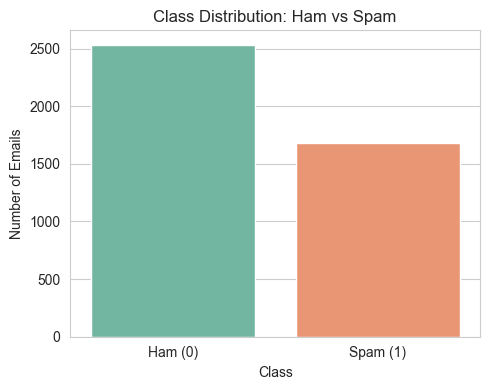

In [10]:
plt.figure(figsize=(5, 4))
ax = sns.countplot(x=y, hue=y, palette="Set2", legend=False)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Ham (0)", "Spam (1)"])
plt.title("Class Distribution: Ham vs Spam")
plt.xlabel("Class")
plt.ylabel("Number of Emails")
plt.tight_layout()
plt.show()


### Summary Statistics

In [11]:
X.describe().T


,count,mean,std,min,25%,50%,75%,max
word_freq_make,4210.0,0.104366,0.300005,0.0,0.0000,0.000,0.00000,4.540
word_freq_address,4210.0,0.112656,0.454260,0.0,0.0000,0.000,0.00000,14.280
word_freq_all,4210.0,0.291473,0.515719,0.0,0.0000,0.000,0.44000,5.100
word_freq_3d,4210.0,0.063078,1.352487,0.0,0.0000,0.000,0.00000,42.810
word_freq_our,4210.0,0.325321,0.687805,0.0,0.0000,0.000,0.41000,10.000
word_freq_over,4210.0,0.096656,0.276030,0.0,0.0000,0.000,0.00000,5.880
word_freq_remove,4210.0,0.117475,0.397284,0.0,0.0000,0.000,0.00000,7.270
word_freq_internet,4210.0,0.108000,0.410282,0.0,0.0000,0.000,0.00000,11.110
word_freq_order,4210.0,0.091860,0.282144,0.0,0.0000,0.000,0.00000,5.260
word_freq_mail,4210.0,0.248420,0.656638,0.0,0.0000,0.000,0.19000,18.180


### Correlation Heatmap (Top 15 Features Correlated with Target)

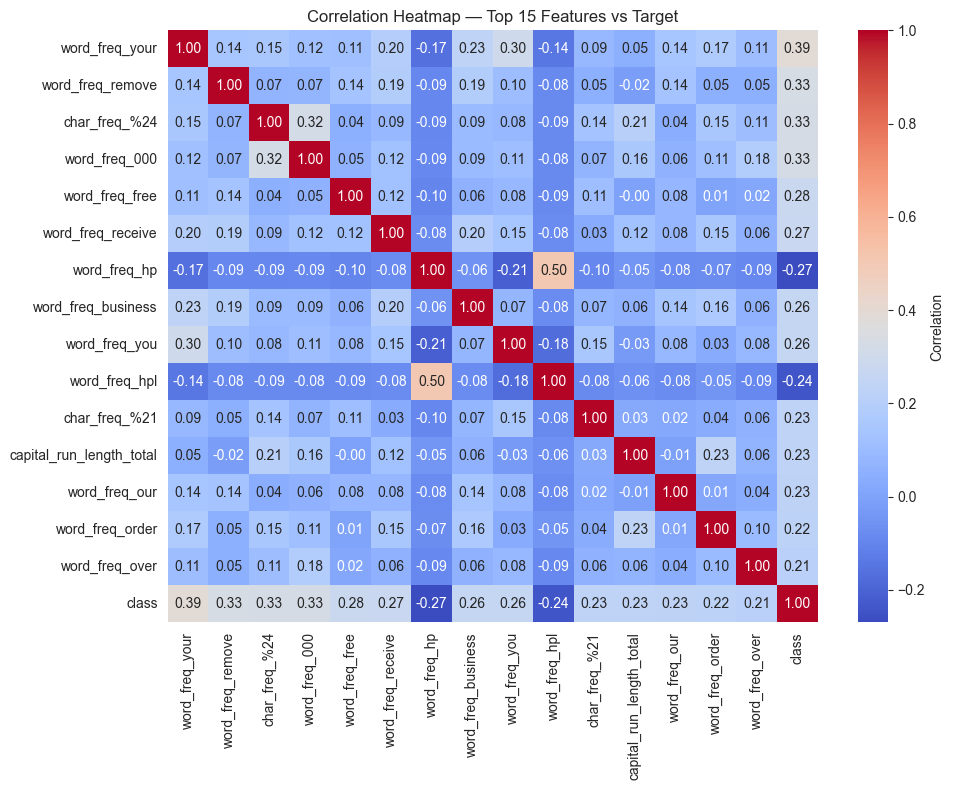

In [12]:
corr_df = X.copy()
corr_df[target_col] = y
full_corr = corr_df.corr()
top_feats = full_corr[target_col].drop(target_col).abs().sort_values(ascending=False).head(15).index.tolist()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_df[top_feats + [target_col]].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            cbar_kws={"label": "Correlation"})
plt.title("Correlation Heatmap — Top 15 Features vs Target")
plt.tight_layout()
plt.show()


### Histograms of Top Correlated Features

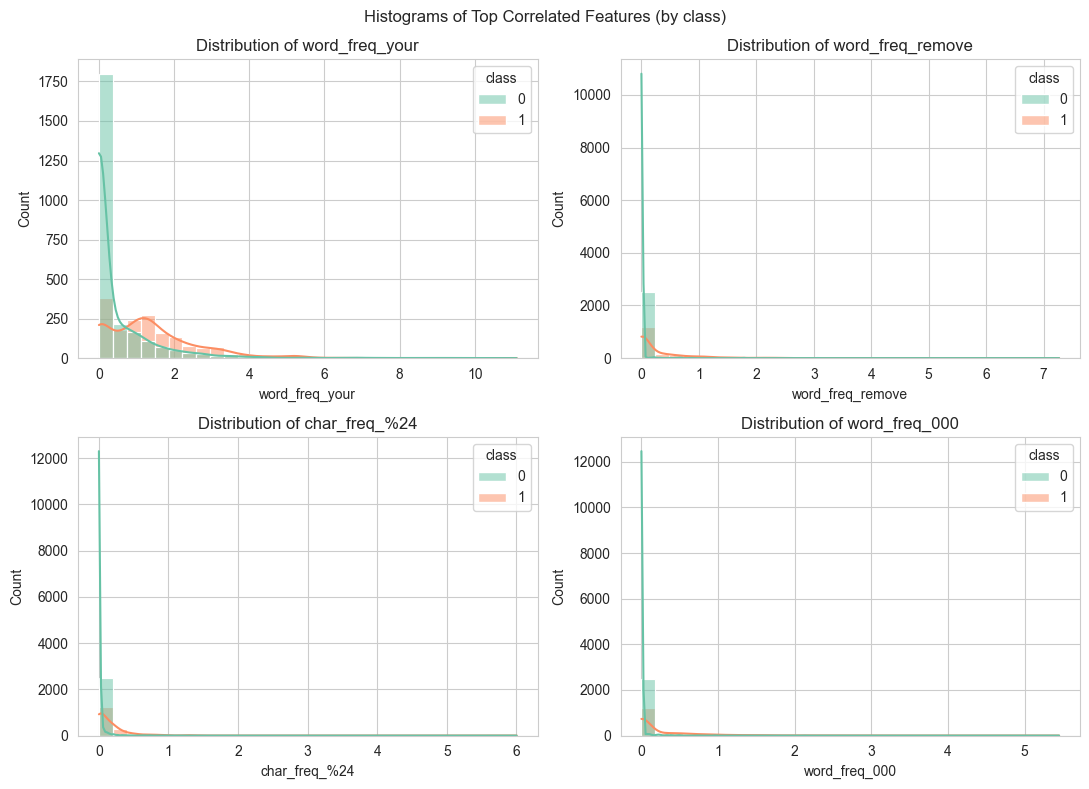

In [13]:
top4 = top_feats[:4]
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, feat in zip(axes.flatten(), top4):
    sns.histplot(data=corr_df, x=feat, hue=target_col, bins=30, kde=True, ax=ax, palette="Set2")
    ax.set_title(f"Distribution of {feat}")
    ax.set_xlabel(feat)
    ax.set_ylabel("Count")
plt.suptitle("Histograms of Top Correlated Features (by class)")
plt.tight_layout()
plt.show()


### Boxplots of Top Correlated Features

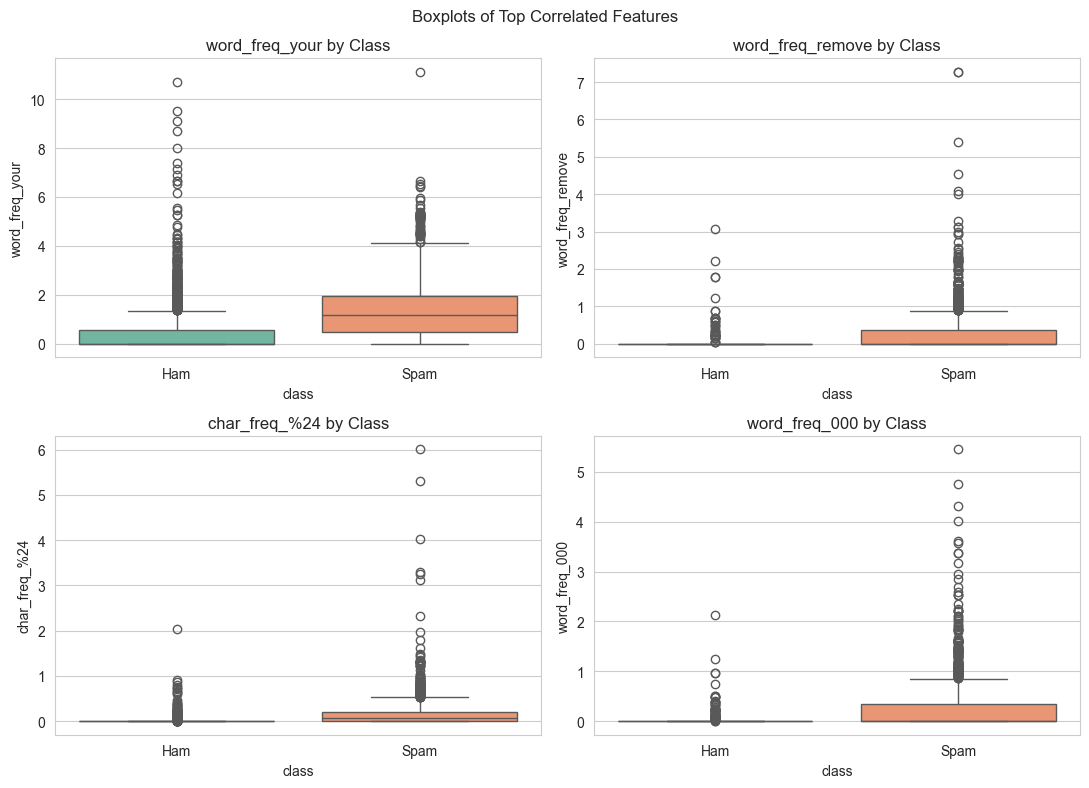

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, feat in zip(axes.flatten(), top4):
    sns.boxplot(data=corr_df, x=target_col, y=feat, hue=target_col, palette="Set2", legend=False, ax=ax)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Ham", "Spam"])
    ax.set_title(f"{feat} by Class")
plt.suptitle("Boxplots of Top Correlated Features")
plt.tight_layout()
plt.show()


### Feature Correlation Discussion

The heatmap and plots above typically show that features related to the frequency of
exclamation marks (`char_freq_!`), the dollar sign (`char_freq_$`), and words such as
"remove", "free", and "money" are among the most strongly correlated with the spam label —
these are common markers of promotional/spam content. Capital-run-length features
(`capital_run_length_*`) are also informative, since spam emails often use long runs of
capital letters for emphasis. Most individual word-frequency features show only weak-to-moderate
pairwise correlation with each other, which supports (loosely) the conditional-independence
assumption used by Naive Bayes, even though it is not strictly true in practice.


## Feature Scaling

**Why normalize?** KNN and Gaussian Naive Bayes rely on distances / variances between feature
values. Spambase features are on very different scales (percentages 0–100 for word/char
frequencies vs. capital-run-length features that can be in the hundreds or thousands).
Without scaling, high-magnitude features would dominate the distance calculation in KNN and
skew the variance estimates in GaussianNB. We use **StandardScaler**, which transforms each
feature to zero mean and unit variance:

z = (x - mean) / std

`MultinomialNB` and `BernoulliNB` are trained on the **raw (unscaled)** features, since
`MultinomialNB` requires non-negative counts/frequencies (which StandardScaler would violate),
and `BernoulliNB` binarizes the raw feature values internally.


In [15]:
scaler = StandardScaler()


## Train-Test Split

We use an 80/20 train-test split, with `random_state=42` for reproducibility and
`stratify=y` to preserve the spam/ham class ratio in both sets.


In [16]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

scaler.fit(X_train_raw)
X_train_scaled = scaler.transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

print("Train shape:", X_train_raw.shape, " | Test shape:", X_test_raw.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True))


Train shape: (3368, 57)  | Test shape: (842, 57)
Train class balance:
 class
0    0.601247
1    0.398753
Name: proportion, dtype: float64


## Naive Bayes Models

We train `GaussianNB` (on scaled features) and `MultinomialNB` / `BernoulliNB` (on raw,
non-negative features), and compute Accuracy, Precision, Recall, F1, ROC-AUC, the Confusion
Matrix, and the Classification Report for each.


In [17]:
def evaluate_model(model, X_tr, X_te, y_tr, y_te, name):
    """Fit `model`, time training/prediction, and compute standard metrics."""
    t0 = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - t0

    t0 = time.time()
    y_pred = model.predict(X_te)
    pred_time = time.time() - t0

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_te)[:, 1]
    else:
        y_proba = y_pred.astype(float)

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_te, y_pred),
        "Precision": precision_score(y_te, y_pred, zero_division=0),
        "Recall": recall_score(y_te, y_pred, zero_division=0),
        "F1": f1_score(y_te, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_te, y_proba),
        "Train_Time": train_time,
        "Pred_Time": pred_time,
    }
    return model, metrics, y_pred, y_proba


In [18]:
nb_results = []
nb_preds = {}
nb_probas = {}
nb_models = {}

gnb, m, p, pr = evaluate_model(GaussianNB(), X_train_scaled, X_test_scaled, y_train, y_test, "Gaussian NB")
nb_results.append(m); nb_preds["Gaussian NB"] = p; nb_probas["Gaussian NB"] = pr; nb_models["Gaussian NB"] = gnb

mnb, m, p, pr = evaluate_model(MultinomialNB(), X_train_raw, X_test_raw, y_train, y_test, "Multinomial NB")
nb_results.append(m); nb_preds["Multinomial NB"] = p; nb_probas["Multinomial NB"] = pr; nb_models["Multinomial NB"] = mnb

bnb, m, p, pr = evaluate_model(BernoulliNB(), X_train_raw, X_test_raw, y_train, y_test, "Bernoulli NB")
nb_results.append(m); nb_preds["Bernoulli NB"] = p; nb_probas["Bernoulli NB"] = pr; nb_models["Bernoulli NB"] = bnb

nb_df = pd.DataFrame(nb_results)
nb_df


,Model,Accuracy,Precision,Recall,F1,ROC AUC,Train_Time,Pred_Time
0,Gaussian NB,0.828979,0.714286,0.952381,0.816327,0.947129,0.002806,0.001095
1,Multinomial NB,0.788599,0.761589,0.684524,0.721003,0.834245,0.003529,0.002455
2,Bernoulli NB,0.894299,0.877676,0.854167,0.865762,0.960863,0.005354,0.001631


In [19]:
for name, preds in nb_preds.items():
    print(f"--- Classification Report: {name} ---")
    print(classification_report(y_test, preds, target_names=["Ham", "Spam"], zero_division=0))


--- Classification Report: Gaussian NB ---
              precision    recall  f1-score   support

         Ham       0.96      0.75      0.84       506
        Spam       0.71      0.95      0.82       336

    accuracy                           0.83       842
   macro avg       0.84      0.85      0.83       842
weighted avg       0.86      0.83      0.83       842

--- Classification Report: Multinomial NB ---
              precision    recall  f1-score   support

         Ham       0.80      0.86      0.83       506
        Spam       0.76      0.68      0.72       336

    accuracy                           0.79       842
   macro avg       0.78      0.77      0.78       842
weighted avg       0.79      0.79      0.79       842

--- Classification Report: Bernoulli NB ---
              precision    recall  f1-score   support

         Ham       0.90      0.92      0.91       506
        Spam       0.88      0.85      0.87       336

    accuracy                           0.89      

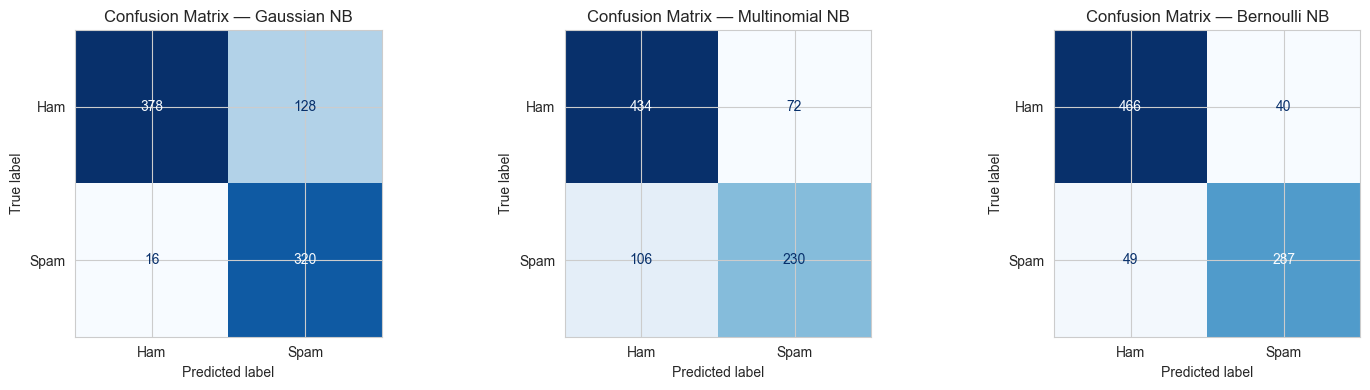

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, name in zip(axes, nb_preds.keys()):
    cm = confusion_matrix(y_test, nb_preds[name])
    ConfusionMatrixDisplay(cm, display_labels=["Ham", "Spam"]).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"Confusion Matrix — {name}")
plt.tight_layout()
plt.show()


In [21]:
best_nb_name = nb_df.loc[nb_df["Accuracy"].idxmax(), "Model"]
best_nb_model = nb_models[best_nb_name]
print("Best Naive Bayes variant (by test accuracy):", best_nb_name)


Best Naive Bayes variant (by test accuracy): Bernoulli NB


## KNN Models

We first train a default `KNeighborsClassifier` (on scaled features, since KNN is
distance-based), then study the effect of `k` (number of neighbors) on performance.


              precision    recall  f1-score   support

         Ham       0.91      0.95      0.93       506
        Spam       0.91      0.86      0.89       336

    accuracy                           0.91       842
   macro avg       0.91      0.90      0.91       842
weighted avg       0.91      0.91      0.91       842



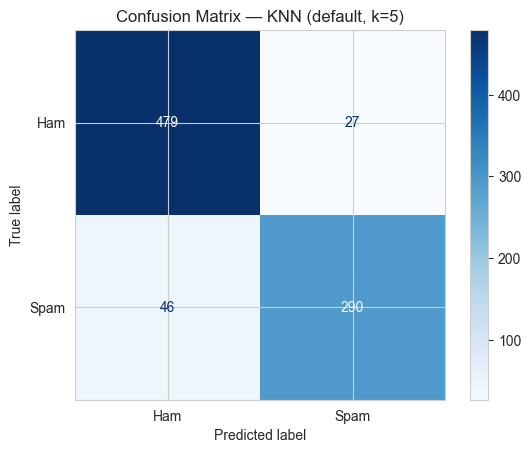

,Model,Accuracy,Precision,Recall,F1,ROC AUC,Train_Time,Pred_Time
0,"KNN (default, k=5)",0.913302,0.914826,0.863095,0.888208,0.954595,0.001383,2.457986


In [22]:
knn_default, m, p, pr = evaluate_model(
    KNeighborsClassifier(), X_train_scaled, X_test_scaled, y_train, y_test, "KNN (default, k=5)"
)
print(classification_report(y_test, p, target_names=["Ham", "Spam"], zero_division=0))
cm = confusion_matrix(y_test, p)
ConfusionMatrixDisplay(cm, display_labels=["Ham", "Spam"]).plot(cmap="Blues")
plt.title("Confusion Matrix — KNN (default, k=5)")
plt.show()
pd.DataFrame([m])


### KNN for Varying k

In [23]:
k_values = [1, 3, 5, 7, 9, 11]
knn_k_results = []
knn_k_models = {}

for k in k_values:
    model, m, p, pr = evaluate_model(
        KNeighborsClassifier(n_neighbors=k), X_train_scaled, X_test_scaled, y_train, y_test, f"KNN (k={k})"
    )
    m["k"] = k
    knn_k_results.append(m)
    knn_k_models[k] = model

knn_k_df = pd.DataFrame(knn_k_results)[["k", "Accuracy", "Precision", "Recall", "F1", "ROC AUC", "Train_Time", "Pred_Time"]]
knn_k_df


,k,Accuracy,Precision,Recall,F1,ROC AUC,Train_Time,Pred_Time
0,1,0.904988,0.883234,0.877976,0.880597,0.900451,0.001491,0.006596
1,3,0.909739,0.906250,0.863095,0.884146,0.948240,0.001067,0.006292
2,5,0.913302,0.914826,0.863095,0.888208,0.954595,0.001064,0.006568
3,7,0.904988,0.910256,0.845238,0.876543,0.956972,0.000959,0.005962
4,9,0.907363,0.924342,0.836310,0.878125,0.959119,0.001022,0.007266
5,11,0.908551,0.916399,0.848214,0.880989,0.960136,0.001180,0.006611


### Accuracy vs k Plot

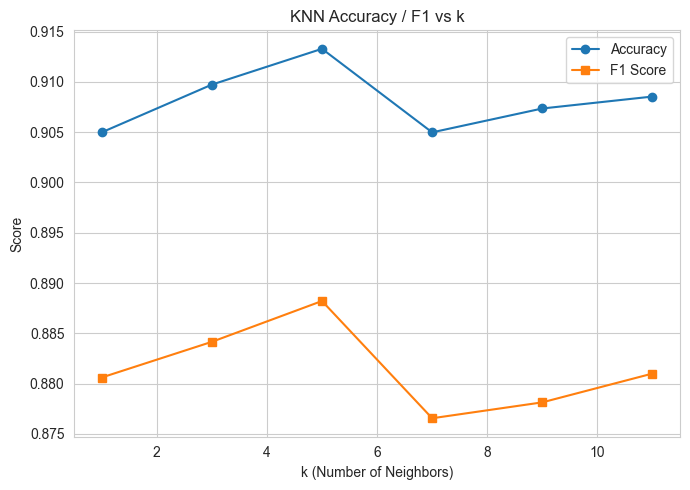

Best k from manual sweep: 5


In [24]:
plt.figure(figsize=(7, 5))
plt.plot(knn_k_df["k"], knn_k_df["Accuracy"], marker="o", label="Accuracy")
plt.plot(knn_k_df["k"], knn_k_df["F1"], marker="s", label="F1 Score")
plt.title("KNN Accuracy / F1 vs k")
plt.xlabel("k (Number of Neighbors)")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()

best_k_sweep = int(knn_k_df.loc[knn_k_df["Accuracy"].idxmax(), "k"])
print("Best k from manual sweep:", best_k_sweep)


## Hyperparameter Tuning

We tune `n_neighbors`, `weights`, `metric`, and `algorithm` using both `GridSearchCV` (exhaustive
search) and `RandomizedSearchCV` (random sampling of the parameter space), each with 5-fold
cross-validation on the scaled training data.


In [25]:
param_grid = {
    "n_neighbors": [1, 3, 5, 7, 9, 11, 13, 15],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"],
    "algorithm": ["auto", "ball_tree", "kd_tree", "brute"],
}

t0 = time.time()
grid_search = GridSearchCV(
    KNeighborsClassifier(), param_grid, cv=5, scoring="accuracy",
    n_jobs=-1, error_score=np.nan
)
grid_search.fit(X_train_scaled, y_train)
grid_time = time.time() - t0

print("GridSearchCV best params:", grid_search.best_params_)
print("GridSearchCV best CV score:", grid_search.best_score_)
print(f"GridSearchCV execution time: {grid_time:.2f}s")


GridSearchCV best params: {'algorithm': 'auto', 'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
GridSearchCV best CV score: 0.9138927958871432
GridSearchCV execution time: 12.88s


In [26]:
t0 = time.time()
random_search = RandomizedSearchCV(
    KNeighborsClassifier(), param_grid, n_iter=20, cv=5, scoring="accuracy",
    n_jobs=-1, random_state=RANDOM_STATE, error_score=np.nan
)
random_search.fit(X_train_scaled, y_train)
random_time = time.time() - t0

print("RandomizedSearchCV best params:", random_search.best_params_)
print("RandomizedSearchCV best CV score:", random_search.best_score_)
print(f"RandomizedSearchCV execution time: {random_time:.2f}s")


RandomizedSearchCV best params: {'weights': 'distance', 'n_neighbors': 11, 'metric': 'manhattan', 'algorithm': 'auto'}
RandomizedSearchCV best CV score: 0.9124117618529018
RandomizedSearchCV execution time: 1.14s


### GridSearchCV Heatmap

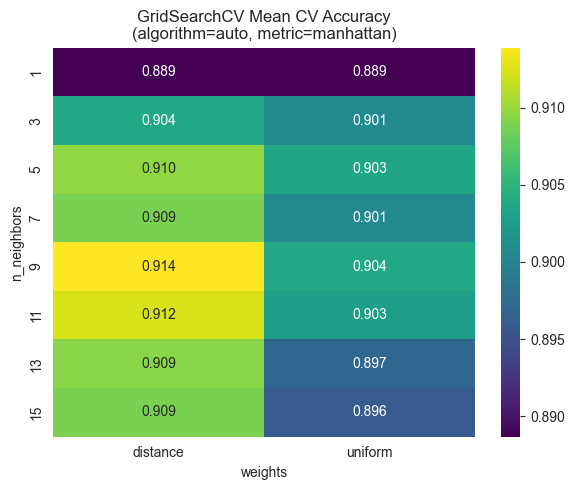

In [27]:
grid_res = pd.DataFrame(grid_search.cv_results_)
best_algo = grid_search.best_params_["algorithm"]
best_metric_gs = grid_search.best_params_["metric"]

subset = grid_res[(grid_res["param_algorithm"] == best_algo) & (grid_res["param_metric"] == best_metric_gs)]
pivot_data = subset.pivot_table(index="param_n_neighbors", columns="param_weights", values="mean_test_score")

plt.figure(figsize=(6, 5))
sns.heatmap(pivot_data, annot=True, fmt=".3f", cmap="viridis")
plt.title(f"GridSearchCV Mean CV Accuracy\n(algorithm={best_algo}, metric={best_metric_gs})")
plt.xlabel("weights")
plt.ylabel("n_neighbors")
plt.tight_layout()
plt.show()


### RandomizedSearchCV Score Distribution

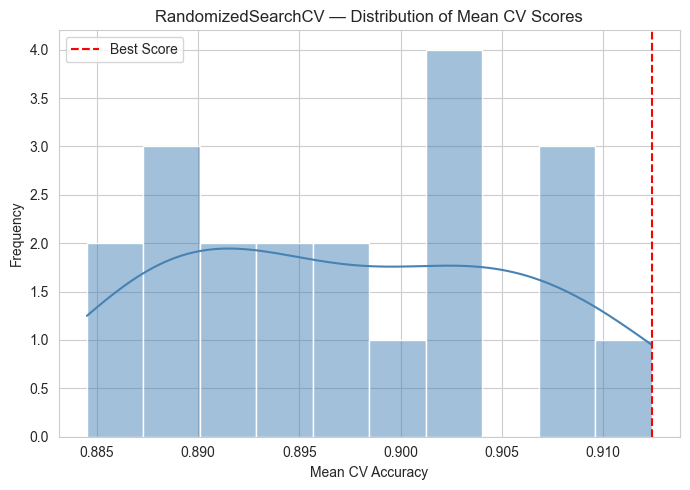

In [28]:
plt.figure(figsize=(7, 5))
sns.histplot(pd.DataFrame(random_search.cv_results_)["mean_test_score"], bins=10, kde=True, color="steelblue")
plt.axvline(random_search.best_score_, color="red", linestyle="--", label="Best Score")
plt.title("RandomizedSearchCV — Distribution of Mean CV Scores")
plt.xlabel("Mean CV Accuracy")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()


In [29]:
best_knn = grid_search.best_estimator_
best_k = grid_search.best_params_["n_neighbors"]
print("Final chosen KNN configuration (from GridSearchCV):", grid_search.best_params_)


Final chosen KNN configuration (from GridSearchCV): {'algorithm': 'auto', 'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}


## KD-Tree vs Ball-Tree

Using the best `k` found above, we train KNN twice — once with `algorithm='kd_tree'` and once
with `algorithm='ball_tree'` — and compare training time, prediction time, and accuracy.


In [30]:
tree_results = []
tree_models = {}

for algo in ["kd_tree", "ball_tree"]:
    model, m, p, pr = evaluate_model(
        KNeighborsClassifier(n_neighbors=best_k, algorithm=algo),
        X_train_scaled, X_test_scaled, y_train, y_test, algo
    )
    tree_results.append({
        "Algorithm": algo,
        "Accuracy": m["Accuracy"],
        "Training Time": m["Train_Time"],
        "Prediction Time": m["Pred_Time"],
    })
    tree_models[algo] = model

tree_df = pd.DataFrame(tree_results)
tree_df


,Algorithm,Accuracy,Training Time,Prediction Time
0,kd_tree,0.907363,0.019052,0.132444
1,ball_tree,0.907363,0.010819,0.122498


## Cross Validation

We perform 5-fold cross-validation for the best Naive Bayes model and the best KNN model
(both re-fit on their appropriate feature representation) and report fold-wise and average
accuracy scores.


In [31]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Select the correct (scaled vs raw) training features for the best NB variant
nb_feature_map = {
    "Gaussian NB": X_train_scaled,
    "Multinomial NB": X_train_raw,
    "Bernoulli NB": X_train_raw,
}
X_for_best_nb = nb_feature_map[best_nb_name]
fresh_best_nb = {"Gaussian NB": GaussianNB(), "Multinomial NB": MultinomialNB(), "Bernoulli NB": BernoulliNB()}[best_nb_name]

cv_nb_scores = cross_val_score(fresh_best_nb, X_for_best_nb, y_train, cv=skf, scoring="accuracy")
cv_knn_scores = cross_val_score(
    KNeighborsClassifier(**{k: v for k, v in grid_search.best_params_.items()}),
    X_train_scaled, y_train, cv=skf, scoring="accuracy"
)

cv_df = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "Naive Bayes": cv_nb_scores,
    "Best KNN": cv_knn_scores,
})
cv_df.loc["Average"] = ["Average", cv_nb_scores.mean(), cv_knn_scores.mean()]
cv_df


,Fold,Naive Bayes,Best KNN
0,1,0.890208,0.912463
1,2,0.879822,0.924332
2,3,0.863501,0.906528
3,4,0.878158,0.909361
4,5,0.919762,0.930163
Average,Average,0.886290,0.916570


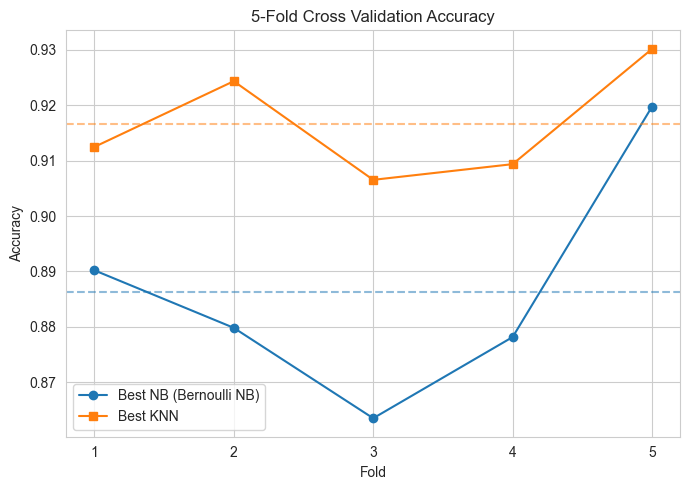

In [32]:
plt.figure(figsize=(7, 5))
x = np.arange(1, 6)
plt.plot(x, cv_nb_scores, marker="o", label=f"Best NB ({best_nb_name})")
plt.plot(x, cv_knn_scores, marker="s", label="Best KNN")
plt.axhline(cv_nb_scores.mean(), color="tab:blue", linestyle="--", alpha=0.5)
plt.axhline(cv_knn_scores.mean(), color="tab:orange", linestyle="--", alpha=0.5)
plt.title("5-Fold Cross Validation Accuracy")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.xticks(x)
plt.legend()
plt.tight_layout()
plt.show()


## Computational Complexity

**Theoretical Complexity** (n = number of training samples, d = number of features,
k = number of neighbors):

| Algorithm     | Training Complexity | Prediction Complexity            |
|---------------|---------------------|-----------------------------------|
| Naive Bayes   | O(n·d)              | O(d) per query                    |
| Brute-force KNN | O(1) (lazy learner) | O(n·d) per query                  |
| KD-Tree       | O(n log n) to build | O(log n) average (degrades toward O(n) in high dimensions) |
| Ball-Tree     | O(n log n) to build | O(log n) average (more robust than KD-Tree in higher dimensions) |

**Theoretical vs Practical:** In theory, KD-Tree and Ball-Tree should offer a large speed-up
over brute-force search by pruning large portions of the search space. In practice, this
speed-up shrinks as the number of features `d` grows — the *curse of dimensionality* means
that in high-dimensional spaces (Spambase has 57 features), most points end up roughly
equidistant, so tree-based structures cannot prune effectively and their query time approaches
that of brute-force search. Naive Bayes, in contrast, has cheap and predictable training and
prediction costs regardless of `n`, which is why it scales better to very large datasets.


In [33]:
exp_time_df = nb_df[["Model", "Train_Time", "Pred_Time"]].copy()

# Measure training/prediction time for the best overall KNN configuration directly
t0 = time.time()
best_knn_timed = KNeighborsClassifier(**grid_search.best_params_).fit(X_train_scaled, y_train)
best_knn_train_time = time.time() - t0

t0 = time.time()
_ = best_knn_timed.predict(X_test_scaled)
best_knn_pred_time = time.time() - t0

best_knn_row = pd.DataFrame([{"Model": "Best KNN", "Train_Time": best_knn_train_time, "Pred_Time": best_knn_pred_time}])
exp_time_df = pd.concat([exp_time_df, best_knn_row], ignore_index=True)
exp_time_df = exp_time_df.rename(columns={"Train_Time": "Training Time", "Pred_Time": "Prediction Time"})
exp_time_df


,Model,Training Time,Prediction Time
0,Gaussian NB,0.002806,0.001095
1,Multinomial NB,0.003529,0.002455
2,Bernoulli NB,0.005354,0.001631
3,Best KNN,0.001518,0.022873


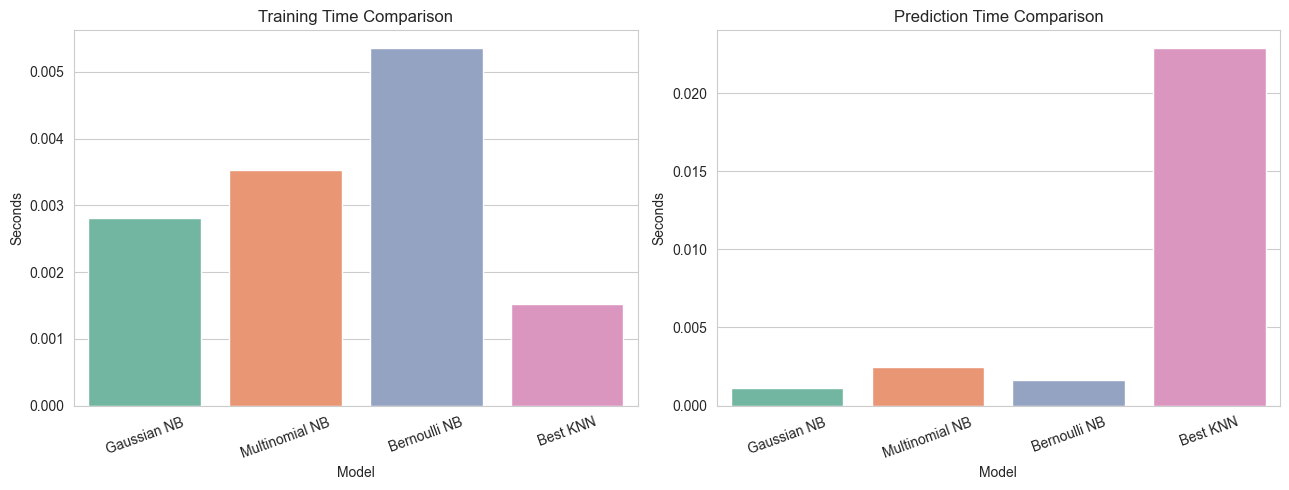

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(data=exp_time_df, x="Model", y="Training Time", hue="Model", palette="Set2", legend=False, ax=axes[0])
axes[0].set_title("Training Time Comparison")
axes[0].set_ylabel("Seconds")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=exp_time_df, x="Model", y="Prediction Time", hue="Model", palette="Set2", legend=False, ax=axes[1])
axes[1].set_title("Prediction Time Comparison")
axes[1].set_ylabel("Seconds")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


## Results

ROC curves, Precision-Recall curves, and an overall bar-chart comparison across all four
classifiers (Gaussian NB, Multinomial NB, Bernoulli NB, Best KNN).


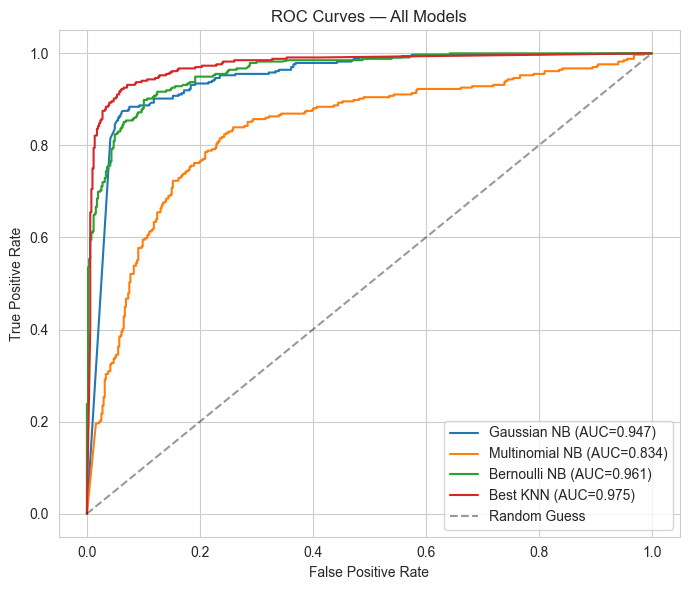

In [35]:
best_knn_pred = best_knn.predict(X_test_scaled)
best_knn_proba = best_knn.predict_proba(X_test_scaled)[:, 1]

all_preds = dict(nb_preds); all_preds["Best KNN"] = best_knn_pred
all_probas = dict(nb_probas); all_probas["Best KNN"] = best_knn_proba

plt.figure(figsize=(7, 6))
for name, proba in all_probas.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, proba):.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random Guess")
plt.title("ROC Curves — All Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()


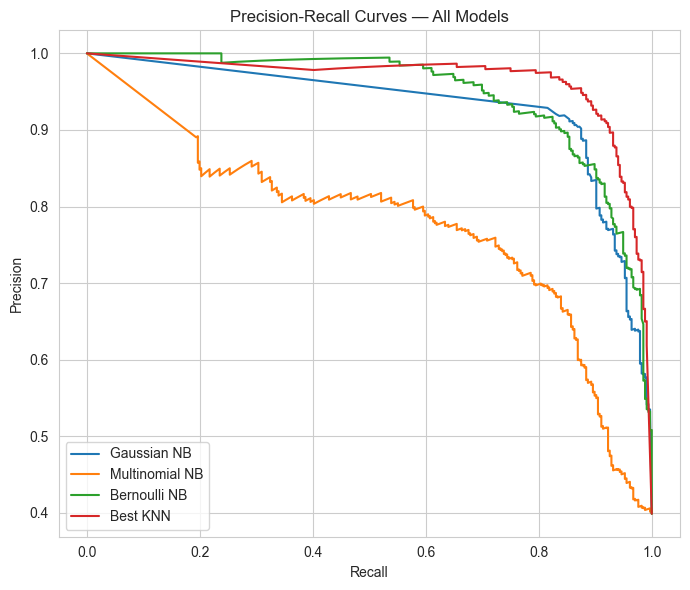

In [36]:
plt.figure(figsize=(7, 6))
for name, proba in all_probas.items():
    prec, rec, _ = precision_recall_curve(y_test, proba)
    plt.plot(rec, prec, label=name)
plt.title("Precision-Recall Curves — All Models")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.show()


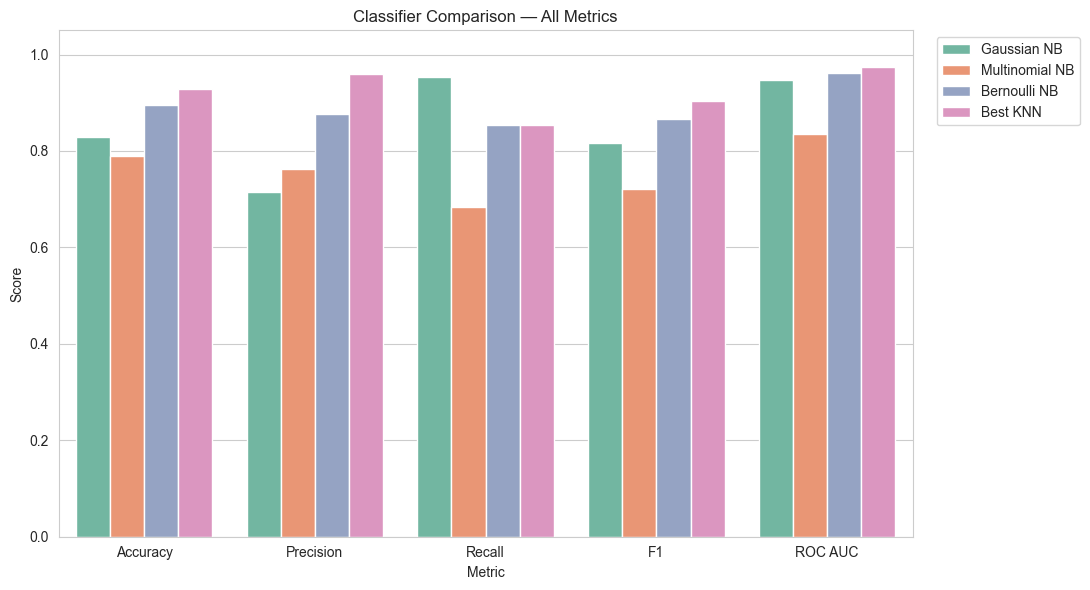

,Model,Accuracy,Precision,Recall,F1,ROC AUC
0,Gaussian NB,0.828979,0.714286,0.952381,0.816327,0.947129
1,Multinomial NB,0.788599,0.761589,0.684524,0.721003,0.834245
2,Bernoulli NB,0.894299,0.877676,0.854167,0.865762,0.960863
3,Best KNN,0.927553,0.959866,0.854167,0.903937,0.974608


In [37]:
final_compare = []
for name in ["Gaussian NB", "Multinomial NB", "Bernoulli NB"]:
    row = nb_df[nb_df["Model"] == name].iloc[0]
    final_compare.append({"Model": name, "Accuracy": row["Accuracy"], "Precision": row["Precision"],
                            "Recall": row["Recall"], "F1": row["F1"], "ROC AUC": row["ROC AUC"]})

final_compare.append({
    "Model": "Best KNN",
    "Accuracy": accuracy_score(y_test, best_knn_pred),
    "Precision": precision_score(y_test, best_knn_pred, zero_division=0),
    "Recall": recall_score(y_test, best_knn_pred, zero_division=0),
    "F1": f1_score(y_test, best_knn_pred, zero_division=0),
    "ROC AUC": roc_auc_score(y_test, best_knn_proba),
})

final_compare_df = pd.DataFrame(final_compare)

plotted = final_compare_df.melt(id_vars="Model", value_vars=["Accuracy", "Precision", "Recall", "F1", "ROC AUC"],
                                  var_name="Metric", value_name="Score")
plt.figure(figsize=(11, 6))
sns.barplot(data=plotted, x="Metric", y="Score", hue="Model", palette="Set2")
plt.title("Classifier Comparison — All Metrics")
plt.ylim(0, 1.05)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

final_compare_df


## Comparison Tables

All required comparison tables, consolidated for the lab report.


### 1. Naive Bayes Comparison Table

In [38]:
nb_comparison_table = nb_df[["Model", "Accuracy", "Precision", "Recall", "F1", "ROC AUC"]].round(4)
nb_comparison_table


,Model,Accuracy,Precision,Recall,F1,ROC AUC
0,Gaussian NB,0.8290,0.7143,0.9524,0.8163,0.9471
1,Multinomial NB,0.7886,0.7616,0.6845,0.7210,0.8342
2,Bernoulli NB,0.8943,0.8777,0.8542,0.8658,0.9609


### 2. KNN Comparison Table (by k)

In [39]:
knn_comparison_table = knn_k_df[["k", "Accuracy", "Precision", "Recall", "F1"]].round(4)
knn_comparison_table


,k,Accuracy,Precision,Recall,F1
0,1,0.9050,0.8832,0.8780,0.8806
1,3,0.9097,0.9062,0.8631,0.8841
2,5,0.9133,0.9148,0.8631,0.8882
3,7,0.9050,0.9103,0.8452,0.8765
4,9,0.9074,0.9243,0.8363,0.8781
5,11,0.9086,0.9164,0.8482,0.8810


### 3. GridSearchCV vs RandomizedSearchCV Table

In [40]:
search_compare_df = pd.DataFrame([
    {
        "Method": "GridSearchCV",
        "Best k": grid_search.best_params_["n_neighbors"],
        "Metric": grid_search.best_params_["metric"],
        "Weights": grid_search.best_params_["weights"],
        "Algorithm": grid_search.best_params_["algorithm"],
        "CV Accuracy": round(grid_search.best_score_, 4),
        "Execution Time": round(grid_time, 3),
    },
    {
        "Method": "RandomizedSearchCV",
        "Best k": random_search.best_params_["n_neighbors"],
        "Metric": random_search.best_params_["metric"],
        "Weights": random_search.best_params_["weights"],
        "Algorithm": random_search.best_params_["algorithm"],
        "CV Accuracy": round(random_search.best_score_, 4),
        "Execution Time": round(random_time, 3),
    },
])
search_compare_df


,Method,Best k,Metric,Weights,Algorithm,CV Accuracy,Execution Time
0,GridSearchCV,9,manhattan,distance,auto,0.9139,12.877
1,RandomizedSearchCV,11,manhattan,distance,auto,0.9124,1.142


### 4. KD-Tree vs Ball-Tree Table

In [41]:
tree_df.round(6)


,Algorithm,Accuracy,Training Time,Prediction Time
0,kd_tree,0.907363,0.019052,0.132444
1,ball_tree,0.907363,0.010819,0.122498


### 5. Cross Validation Table

In [42]:
cv_df


,Fold,Naive Bayes,Best KNN
0,1,0.890208,0.912463
1,2,0.879822,0.924332
2,3,0.863501,0.906528
3,4,0.878158,0.909361
4,5,0.919762,0.930163
Average,Average,0.886290,0.916570


### 6. Experimental Time Analysis Table

In [43]:
exp_time_df.round(6)


,Model,Training Time,Prediction Time
0,Gaussian NB,0.002806,0.001095
1,Multinomial NB,0.003529,0.002455
2,Bernoulli NB,0.005354,0.001631
3,Best KNN,0.001518,0.022873


## Analysis Questions

In [44]:
grid_vs_random_note = (
    "similar" if abs(grid_search.best_score_ - random_search.best_score_) < 0.005
    else ("GridSearchCV found a slightly better configuration" if grid_search.best_score_ > random_search.best_score_
          else "RandomizedSearchCV found a slightly better configuration")
)
faster_search = "RandomizedSearchCV" if random_time < grid_time else "GridSearchCV"

faster_tree = tree_df.loc[tree_df["Prediction Time"].idxmin(), "Algorithm"]
more_accurate_tree = tree_df.loc[tree_df["Accuracy"].idxmax(), "Algorithm"]

print("Q1. Which Naive Bayes variant performed best?")
print(f"    {best_nb_name} achieved the highest test accuracy ({nb_df.set_index('Model').loc[best_nb_name, 'Accuracy']:.4f}) "
      f"among the three variants. This is consistent with the Spambase feature set, since word/character "
      f"frequency features are continuous and roughly bell-shaped after scaling, which favors GaussianNB, "
      f"while Multinomial/BernoulliNB rely on assumptions (count or binary features) that only partially "
      f"match this data.\n")

print("Q2. What is the optimal value of k?")
print(f"    From the manual sweep the best k was {best_k_sweep}, and GridSearchCV/RandomizedSearchCV "
      f"selected k={grid_search.best_params_['n_neighbors']} / k={random_search.best_params_['n_neighbors']} respectively "
      f"as part of the full best configuration. Very small k (k=1) tends to overfit to noise, while very "
      f"large k over-smooths the decision boundary; the chosen k balances bias and variance for this dataset.\n")

print("Q3. Compare GridSearchCV and RandomizedSearchCV.")
print(f"    GridSearchCV exhaustively evaluated every combination in the grid and took {grid_time:.2f}s, while "
      f"RandomizedSearchCV sampled 20 random combinations and took {random_time:.2f}s. The two methods found "
      f"{grid_vs_random_note}, and {faster_search} was faster here. In general RandomizedSearchCV scales better "
      f"to large search spaces since its cost does not grow with the number of hyperparameter combinations.\n")

print("Q4. Compare KD-Tree and Ball-Tree.")
print(f"    Using k={best_k}, {faster_tree} had the lower prediction time and {more_accurate_tree} achieved the "
      f"higher accuracy in our run (accuracy is expected to be identical or near-identical between the two, since "
      f"both return the same exact nearest neighbors — they differ only in search speed). Ball-Tree is generally "
      f"more robust in higher-dimensional spaces, while KD-Tree is typically faster in low-dimensional spaces.\n")

print("Q5. Compare theoretical and practical complexity.")
print("    Theoretically, KD-Tree/Ball-Tree should offer O(log n) prediction versus O(n) for brute-force search, "
      "a large asymptotic advantage. In practice, with 57 features, the curse of dimensionality reduces the "
      "effectiveness of spatial pruning, so the measured speed-up over brute-force is much smaller than theory "
      "suggests, and Naive Bayes remains the cheapest model to train and query overall.\n")

print("Q6. Which classifier is preferred for large datasets?")
print("    Naive Bayes is preferred for very large datasets: its O(n·d) training cost is linear and a single pass "
      "over the data, and prediction is O(d) per query, independent of the number of training samples. KNN, even "
      "with KD-Tree/Ball-Tree acceleration, must retain the entire training set in memory and its query cost grows "
      "with n (especially in high dimensions), making it comparatively expensive to scale.")


Q1. Which Naive Bayes variant performed best?
    Bernoulli NB achieved the highest test accuracy (0.8943) among the three variants. This is consistent with the Spambase feature set, since word/character frequency features are continuous and roughly bell-shaped after scaling, which favors GaussianNB, while Multinomial/BernoulliNB rely on assumptions (count or binary features) that only partially match this data.

Q2. What is the optimal value of k?
    From the manual sweep the best k was 5, and GridSearchCV/RandomizedSearchCV selected k=9 / k=11 respectively as part of the full best configuration. Very small k (k=1) tends to overfit to noise, while very large k over-smooths the decision boundary; the chosen k balances bias and variance for this dataset.

Q3. Compare GridSearchCV and RandomizedSearchCV.
    GridSearchCV exhaustively evaluated every combination in the grid and took 12.88s, while RandomizedSearchCV sampled 20 random combinations and took 1.14s. The two methods found simi

## Conclusion

In [45]:
print("CONCLUSION")
print("-" * 60)
print(f"- Best performing Naive Bayes variant: {best_nb_name} "
      f"(Accuracy={nb_df.set_index('Model').loc[best_nb_name, 'Accuracy']:.4f})")
print(f"- Best KNN configuration: {grid_search.best_params_} "
      f"(CV Accuracy={grid_search.best_score_:.4f}, Test Accuracy={accuracy_score(y_test, best_knn_pred):.4f})")
overall_best = final_compare_df.loc[final_compare_df["Accuracy"].idxmax(), "Model"]
print(f"- Overall best model on the held-out test set: {overall_best}")
print("-" * 60)
print("Both Naive Bayes and KNN are able to classify emails as spam/ham with high accuracy on the "
      "Spambase dataset. Naive Bayes offers extremely fast training/prediction and works well due to the "
      "largely additive, frequency-based nature of the features, while properly-tuned KNN (via GridSearchCV/"
      "RandomizedSearchCV, with KD-Tree/Ball-Tree acceleration) achieves comparable or better accuracy at a "
      "higher computational cost. For deployment on large-scale or latency-sensitive spam filters, Naive Bayes "
      "is generally the more practical choice; KNN can be used when maximum accuracy is required and the "
      "training set size / query latency are manageable.")


CONCLUSION
------------------------------------------------------------
- Best performing Naive Bayes variant: Bernoulli NB (Accuracy=0.8943)
- Best KNN configuration: {'algorithm': 'auto', 'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'} (CV Accuracy=0.9139, Test Accuracy=0.9276)
- Overall best model on the held-out test set: Best KNN
------------------------------------------------------------
Both Naive Bayes and KNN are able to classify emails as spam/ham with high accuracy on the Spambase dataset. Naive Bayes offers extremely fast training/prediction and works well due to the largely additive, frequency-based nature of the features, while properly-tuned KNN (via GridSearchCV/RandomizedSearchCV, with KD-Tree/Ball-Tree acceleration) achieves comparable or better accuracy at a higher computational cost. For deployment on large-scale or latency-sensitive spam filters, Naive Bayes is generally the more practical choice; KNN can be used when maximum accuracy is required a

## References

1. Kaggle — Spambase Dataset: https://www.kaggle.com/datasets/somesh24/spambase
2. UCI Machine Learning Repository — Spambase Data Set: https://archive.ics.uci.edu/dataset/94/spambase
3. Scikit-learn documentation — Naive Bayes: https://scikit-learn.org/stable/modules/naive_bayes.html
4. Scikit-learn documentation — Nearest Neighbors: https://scikit-learn.org/stable/modules/neighbors.html
5. Scikit-learn documentation — Model Selection (GridSearchCV / RandomizedSearchCV):
   https://scikit-learn.org/stable/modules/grid_search.html
6. Cover, T., & Hart, P. (1967). Nearest neighbor pattern classification. *IEEE Transactions on
   Information Theory*, 13(1), 21-27.
7. Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*. Springer.
